In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
%matplotlib inline

In [3]:
df = pd.read_csv("2-multiplegradesdataset.csv")

In [4]:
df.head()

,Study Hours,Sleep Hours,Attendance Rate,Social Media Hours,Exam Score
0,4.7,7.3,82.9,3.3,80.7
1,3.8,6.6,87.9,3.3,76.0
2,5.0,6.3,88.3,2.3,89.1
3,6.3,7.6,86.0,3.2,95.9
4,3.6,8.0,89.2,3.3,70.5


In [5]:
df.describe()

,Study Hours,Sleep Hours,Attendance Rate,Social Media Hours,Exam Score
count,50.00000,50.000000,50.000000,50.00000,50.00000
mean,3.66800,7.022000,89.736000,3.09000,76.07000
std,1.40123,0.874419,4.924813,0.89699,11.70915
min,1.10000,4.400000,80.400000,1.50000,56.90000
25%,2.67500,6.500000,85.625000,2.22500,68.07500
50%,3.60000,7.050000,90.100000,3.20000,73.55000
75%,4.50000,7.575000,92.550000,3.57500,84.17500
max,6.80000,8.600000,100.000000,5.70000,100.00000


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Study Hours         50 non-null     float64
 1   Sleep Hours         50 non-null     float64
 2   Attendance Rate     50 non-null     float64
 3   Social Media Hours  50 non-null     float64
 4   Exam Score          50 non-null     float64
dtypes: float64(5)
memory usage: 2.1 KB


In [7]:
df.isnull().sum()

Study Hours           0
Sleep Hours           0
Attendance Rate       0
Social Media Hours    0
Exam Score            0
dtype: int64

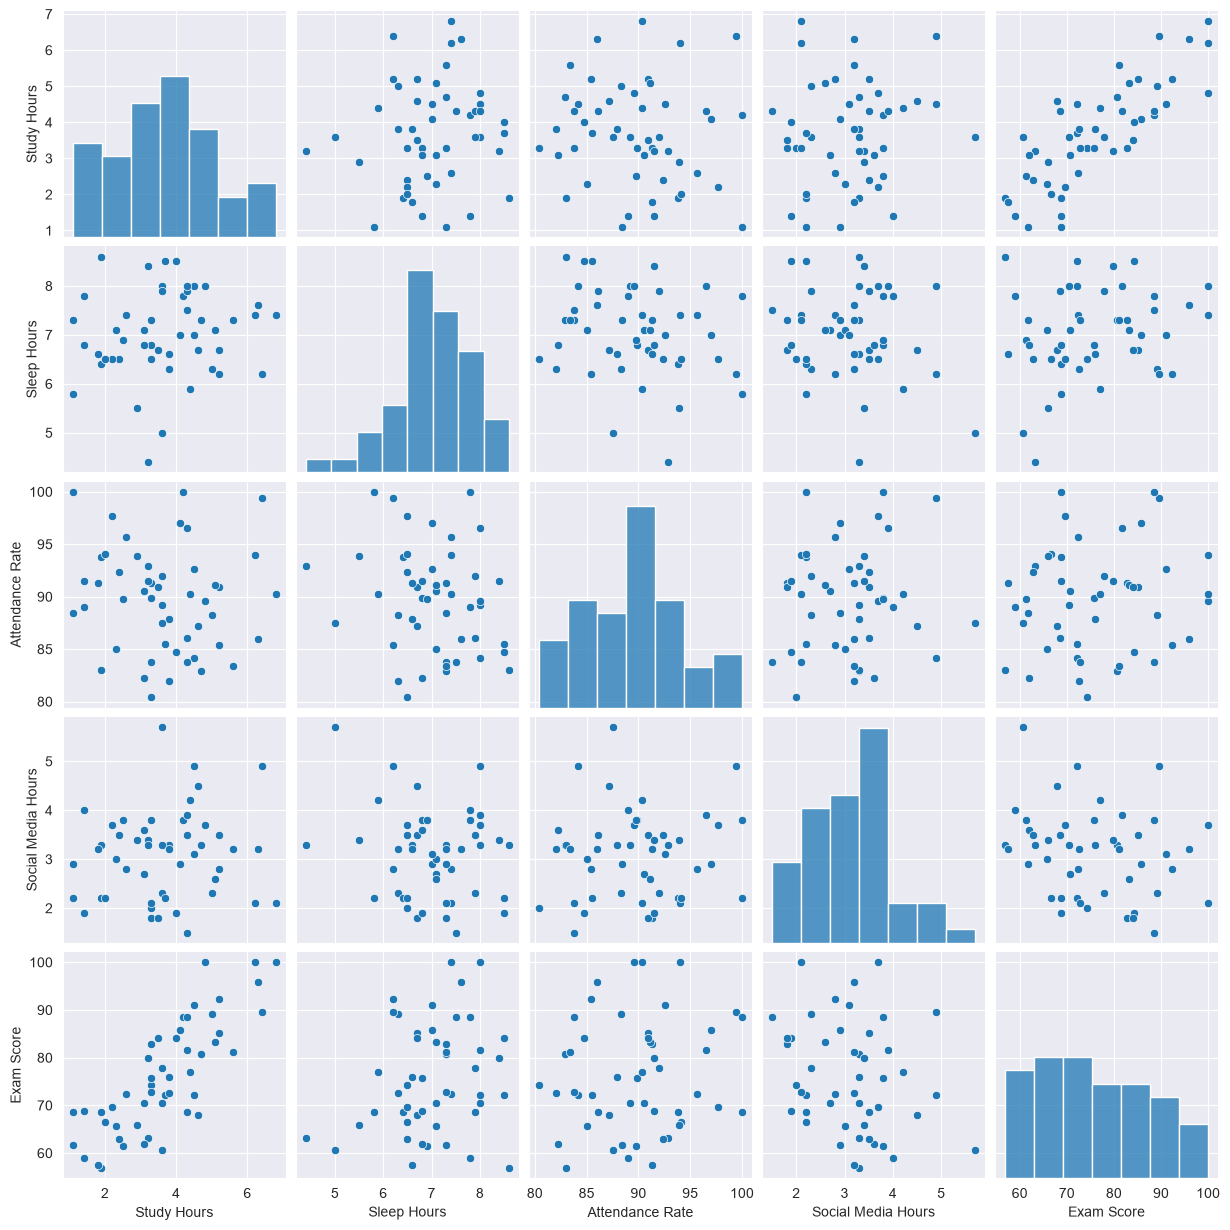

In [9]:
sns.pairplot(df)
plt.show()

In [19]:
df.corr()["Exam Score"]

Study Hours           0.804266
Sleep Hours           0.227694
Attendance Rate       0.123791
Social Media Hours   -0.248743
Exam Score            1.000000
Name: Exam Score, dtype: float64

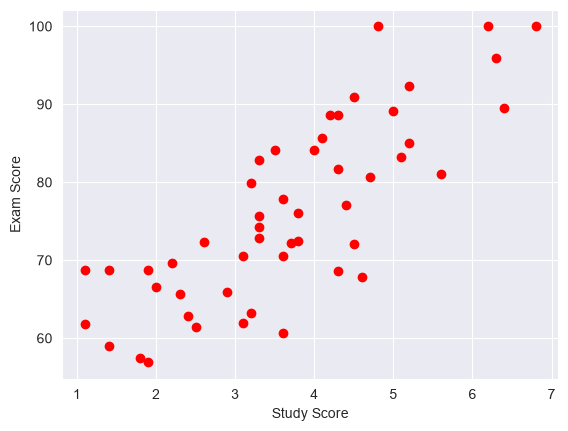

In [26]:
plt.scatter(df["Study Hours"], df["Exam Score"], color="red")
plt.xlabel("Study Score")
plt.ylabel("Exam Score")
plt.show()

<Axes: xlabel='Study Hours', ylabel='Exam Score'>

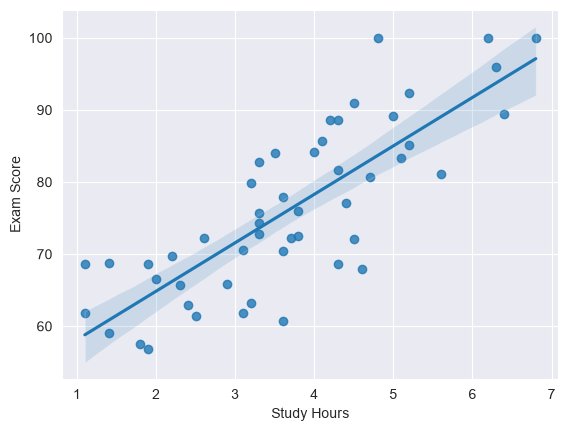

In [22]:
sns.regplot(x = df["Study Hours"], y = df["Exam Score"])

In [29]:
#independent and dependent features
X = df.iloc[:, :-1] #son kolon hariç hepsini al
y = df.iloc[:, -1] # son kolonu al
# (ama eğer hedef yani y yani exam score sondaysa doğru çalışır.)

X = df[["Study Hours" , "Sleep Hours","Attendance Rate","Social Media Hours"]]
y = df["Exam Score"]

In [30]:
y.head()

0    80.7
1    76.0
2    89.1
3    95.9
4    70.5
Name: Exam Score, dtype: float64

In [31]:
#train - test split

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)

In [34]:
from sklearn.preprocessing import StandardScaler

In [35]:
scaler = StandardScaler()

In [36]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [37]:
X_train

array([[-0.37204231,  0.33572221,  0.35358346, -1.47665184],
       [ 1.75665339,  0.68728036, -0.81371815,  0.12022844],
       [ 1.82760991, -0.95332438,  2.13757271,  2.05929734],
       [ 0.33752292,  1.15602457,  1.49886051,  0.91866857],
       [-0.37204231,  0.33572221, -1.29825844, -1.13446321],
       [ 1.25995773,  0.33572221, -1.38635668,  0.12022844],
       [-0.44299884,  1.62476879,  0.39763257,  0.34835419],
       [ 0.69230554,  1.15602457, -0.02083404,  0.69054282],
       [-0.9396945 , -0.13302201,  0.02321508,  0.8046057 ],
       [-0.44299884, -3.06267333,  0.70597639,  0.23429131],
       [ 0.97613163, -0.95332438, -0.94586551, -0.33602307],
       [ 2.11143601,  0.45290826,  0.13333787, -1.13446321],
       [ 0.62134902,  0.33572221, -1.49647947,  0.23429131],
       [-1.43639016, -0.48458016,  0.35358346,  0.12022844],
       [ 0.55039249, -0.36739411, -0.54942345,  1.60304584],
       [-1.01065102, -0.60176622,  0.5958536 ,  0.46241707],
       [-0.15917274,  1.

In [38]:
from sklearn.linear_model import LinearRegression

In [39]:
regression = LinearRegression()

In [40]:
regression.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[10.17, 1.43, 2.6 ,-3.64]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,76.72
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](4,)","[6.99,6.19,5.74,5.28]"


In [42]:
X_test[0]

array([-1.93308583, -1.42206859,  2.26972006, -1.02040033])

In [43]:
df.iloc[0]

Study Hours            4.7
Sleep Hours            7.3
Attendance Rate       82.9
Social Media Hours     3.3
Exam Score            80.7
Name: 0, dtype: float64

In [44]:
new_student = [[5,7,90,2]]

In [45]:
new_student_scaled = scaler.transform(new_student)

C:\Users\busra\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [46]:
regression.predict(new_student_scaled)

array([89.90613009])

In [47]:
#prediction

In [48]:
y_pred = regression.predict(X_test)

In [49]:
y_pred

array([64.65631656, 84.21781786, 64.74440895, 68.66076963, 72.59590158,
       83.21624374, 63.57138016, 83.71951916, 82.5788058 , 67.88042771,
       74.76584222, 75.61587239, 57.6106452 ])

In [50]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [52]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
score = r2_score(y_test, y_pred)

print("mse = ",mse)
print("mae = ",mae)
print("r2 score = ",score)

mse =  14.840108358882294
mae =  3.3384580104363577
r2 score =  0.8549634217448544


In [53]:
#adjusted score
1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.7824451326172817

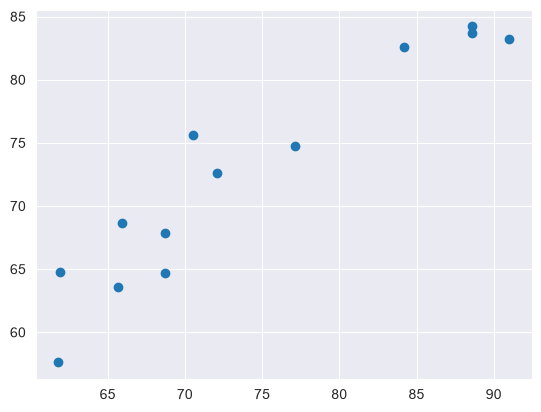

In [54]:
plt.scatter(y_test,y_pred)
plt.show()

In [55]:
residuals = y_test - y_pred

In [56]:
print(residuals)

13    4.043683
39    4.382182
30   -2.844409
45   -2.760770
17   -0.495902
48    7.783756
26    2.128620
25    4.880481
32    1.621194
19    0.819572
12    2.334158
4    -5.115872
37    4.189355
Name: Exam Score, dtype: float64


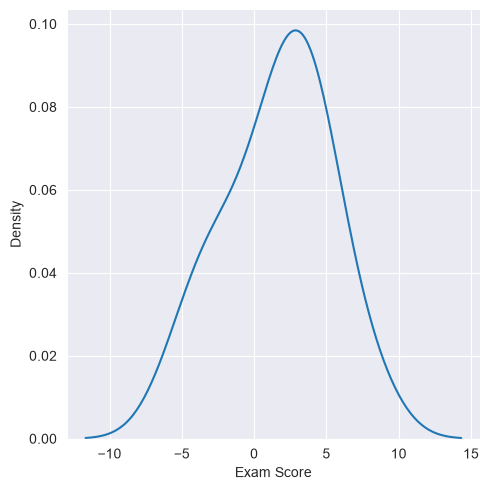

In [58]:
sns.displot(residuals,kind="kde")
plt.show()

In [59]:
regression.intercept_

np.float64(76.72162162162164)

In [60]:
regression.coef_

array([10.16883216,  1.42717312,  2.60099488, -3.6435975 ])

In [61]:
new_student

[[5, 7, 90, 2]]

In [62]:
students = [
    [6,8,95,5],
    [3,6,85,4],
    [4,7,80,3]
]

In [63]:
regression.predict(scaler.transform(students))

C:\Users\busra\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([89.19033956, 62.62651024, 72.80611178])